# Intraday Put-Call Parity Trades

In this exercise we consider the put-call parity arbitrage. This is known as trading **reversals** and **conversions**.

### Intraday Trading

We have data at various points throughout a trading day. (We collect data every 5 minutes, but there are many intervals in which there is not a trade of both a put and a call. Thus, the data of interest is a smaller subset of data points.)

At every synchronous point, we examine the put-call parity and construct an arbitrage if available.

To avoid trades which would be overwhelmed by transaction costs, we will only put on the arbitrage if put-call parity is violated by at least `0.30` in either direction.

### Data Set

Consider the data in the file

`../data/intraday_options_data_NFLX.xlsx`
* `Info` - find the financing rate and days to expiration.
* `Prices` - collects the price at the end of every 5-min period for which we have data on all three instruments.
* `Options` - extra data which is unnecessary for this exercise.
* `Underlying` - extra data which is unnecessary for this exercise.

Note that
* the interest rate is specific to the horizon to expiration, quoted as ACT/360 with simple compounding.
* there is no dividend.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

TICK = 'NFLX'
THRESHOLD = 0.30

# Load data from Excel file
excel_file = f'./data/intraday_options_data_{TICK}.xlsx'

# Read each sheet
info = pd.read_excel(excel_file, sheet_name='Info', index_col=None)
prices = pd.read_excel(excel_file, sheet_name='Prices', index_col=0, parse_dates=True)

In [68]:
display(info)
display(prices)

,Parameter,Value
0,Ticker,NFLX
1,Date,2025-07-25
2,Strike Price,$1180.0
3,Finance Rate,4.5866%
4,Dividend Yield,0.0000%
5,Days to Expiry,21
6,Call Ticker,NFLX 08/15/25 C1180 US Equity
7,Put Ticker,NFLX 08/15/25 P1180 US Equity


,underlying,call,put
2025-07-25 09:30:00,1179.58,29.47,27.95
2025-07-25 09:55:00,1178.05,29.00,28.80
2025-07-25 10:10:00,1186.58,34.00,24.47
2025-07-25 10:30:00,1177.59,29.07,27.60
2025-07-25 10:45:00,1182.92,31.91,25.85
2025-07-25 11:20:00,1184.56,32.30,24.95
2025-07-25 11:35:00,1181.90,31.20,26.10
2025-07-25 12:30:00,1185.55,32.30,24.46
2025-07-25 12:50:00,1186.14,32.50,23.75
2025-07-25 12:55:00,1185.76,33.55,23.42


### 1.1.

For every time stamp, calculate the violation of put-call parity.
* Plot the violations over time.
* Report the mean absolution violation.
* Report how many times the violation is larger than our threshold, in either direction.

Mean Absolute Violation: $0.56
Number of Violations above Threshold: 8


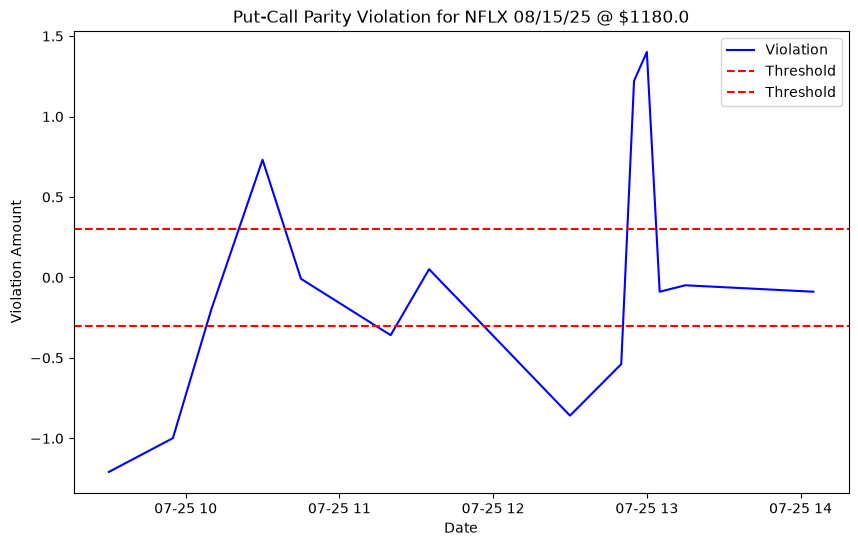

In [58]:
# Interest rate and days to expiration
rate = float(info['Value'][3].replace('%', '')) / 100
days = int(info['Value'][5])
K = float(info['Value'][2].replace('$', '').replace(',', ''))
PV_K = K / (1 + rate * days / 360)

# Formula: c - p = S - K, asssuming no interest rate and no dividends, 
# where c = call price, p = put price, S = stock price, K = strike price (cash-secured)
violation = []
for i in range(len(prices)):
    row = prices.iloc[i]
    S = row['underlying']
    c = row['call']
    p = row['put']

    # calculate violation
    violation_amount = (c - p) - (S - PV_K)
    violation.append(violation_amount)    

# Plot violation in line chart
plt.figure(figsize=(10, 6))
plt.plot(prices.index, violation, label='Violation', color='blue')
plt.axhline(y=THRESHOLD, color='red', linestyle='--', label='Threshold')
plt.axhline(y=-THRESHOLD, color='red', linestyle='--', label='Threshold')
plt.title(f'Put-Call Parity Violation for {TICK} 08/15/25 @ ${K}')
plt.xlabel('Date')
plt.ylabel('Violation Amount')
plt.legend()

# print mean absolute violation
mean_violation = np.mean(np.abs(violation))
print(f'Mean Absolute Violation: ${mean_violation:.2f}')    

# Count number of violations above threshold
num_violations = sum(abs(v) > THRESHOLD for v in violation)
print(f'Number of Violations above Threshold: {num_violations}')

### 1.2.

Calculate the total arbitrage profit if we were to trade every violation at a quantity of `1,000` contracts (`100` shares each.) 

* Report the total PnL for the day.
* Plot the transaction PnL at each trade
* Plot the cumulative PnL over the day

Note that 
* we are assuming that if the violation appears in consecutive time stamps (even just 5 min apart) we can trade it both times.
* we only trade violations beyond the threshold described above.

Hint: You don't need to construct the full trade at each timestamp to answer this question.

Total Profit from Violations: $731737.06


<function matplotlib.pyplot.ylabel(ylabel: 'str', fontdict: 'dict[str, Any] | None' = None, labelpad: 'float | None' = None, *, loc: "Literal['bottom', 'center', 'top'] | None" = None, **kwargs) -> 'Text'>

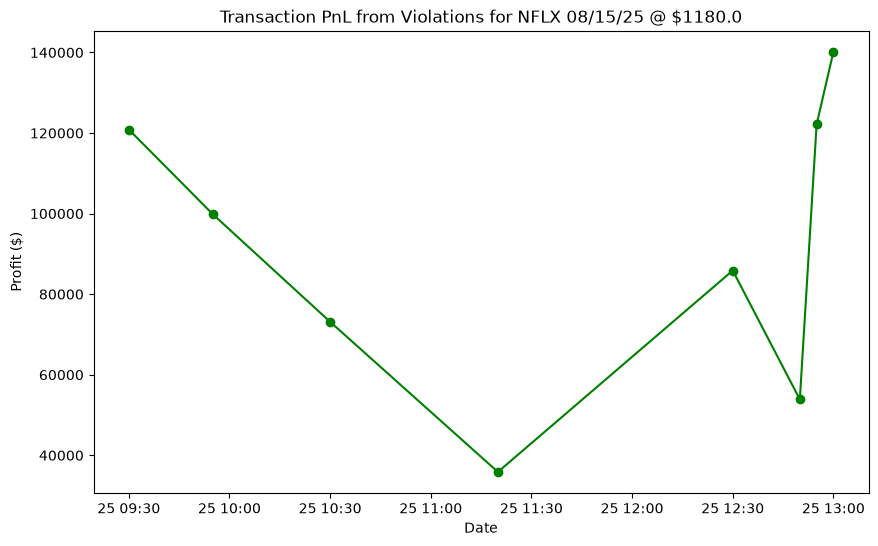

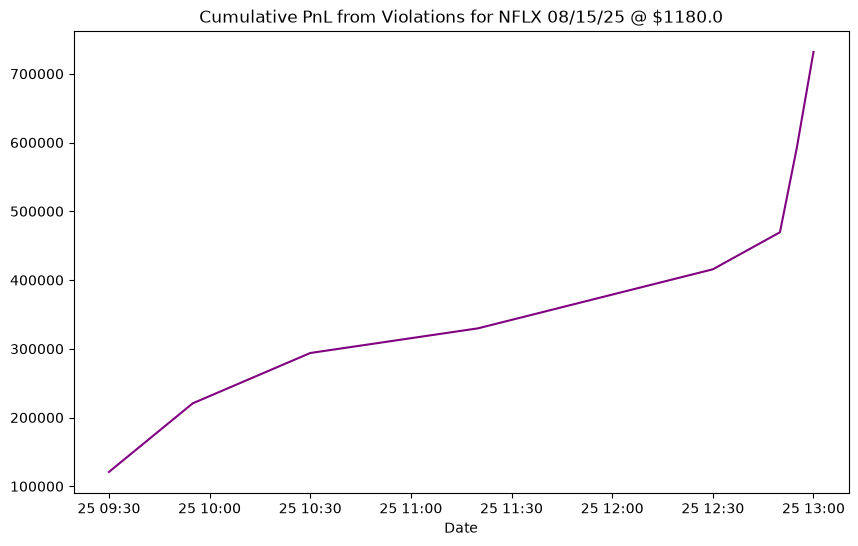

In [69]:
# Trade violations at 1000 contracts, 100 shares each (ignoring commission and other fees)
violation_amounts = np.array(violation)
tradable_violations = violation_amounts[abs(violation_amounts) > THRESHOLD]
violation_profit = abs(tradable_violations) * 1000 * 100  # 1000 contracts, 100 shares each
total_profit = np.sum(violation_profit) 
print(f'Total Profit from Violations: ${total_profit:.2f}')

# Plot transaction PnL at each trade
plt.figure(figsize=(10, 6))
plt.plot(
    prices.index[np.abs(violation_amounts) > THRESHOLD],
    violation_profit,
    marker='o',
    color='green'
)
plt.title(f'Transaction PnL from Violations for {TICK} 08/15/25 @ ${K}')
plt.xlabel('Date')
plt.ylabel('Profit ($)')      

# Plot cumualative PnL
cumulative_profit = np.cumsum(violation_profit)
plt.figure(figsize=(10, 6))
plt.plot(prices.index[abs(violation_amounts) > THRESHOLD], cumulative_profit, color='purple')
plt.title(f'Cumulative PnL from Violations for {TICK} 08/15/25 @ ${K}')
plt.xlabel('Date')  
plt.ylabel    



### 1.3.

Construct a plot of the cumulative position we hold in calls, puts, shares, and cash throughout the day.

In a table, report the max and min of number
* shares
* call contracts
* put contracts

,Minimum,Maximum
Shares,"-400,000","-100,000"
Call contracts,"1,000","4,000"
Put contracts,"-4,000","-1,000"


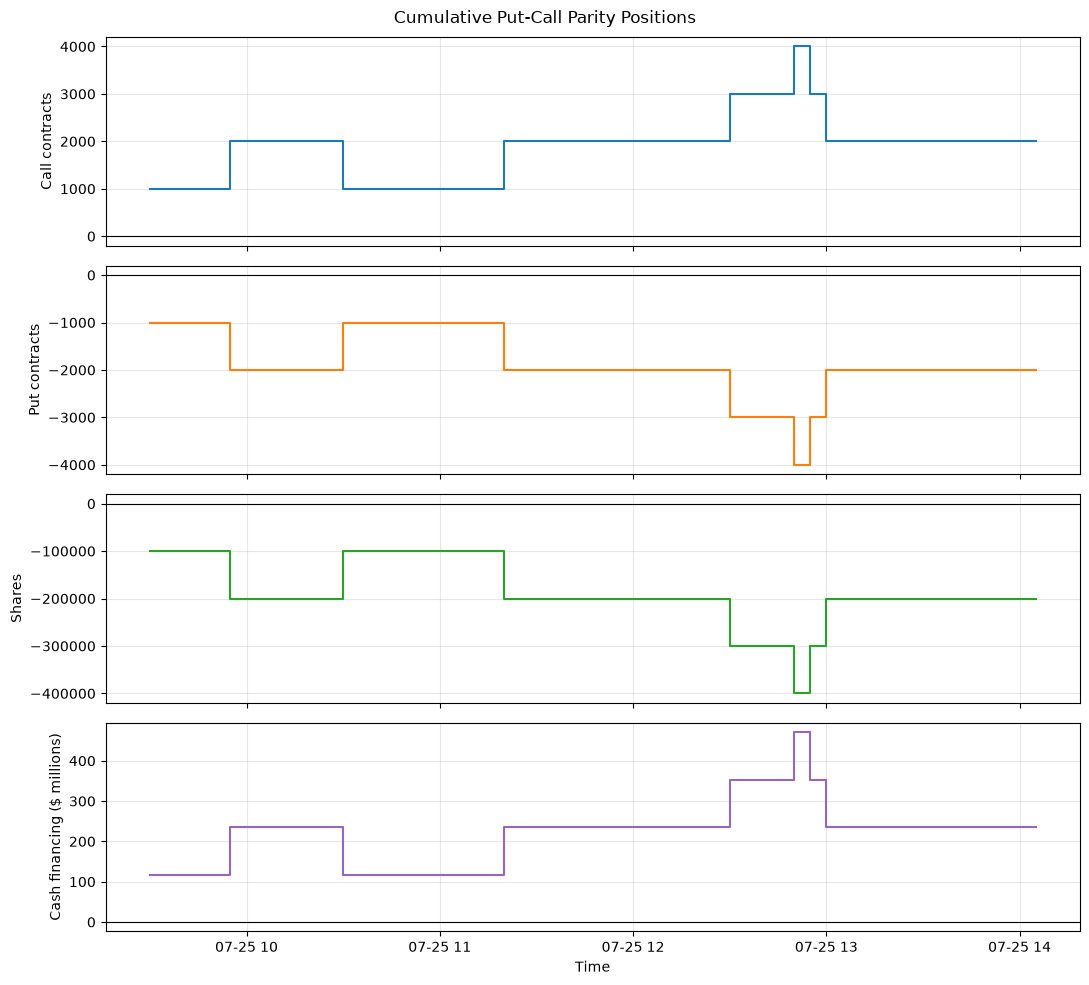

In [91]:
N_CONTRACTS = 1_000
CONTRACT_MULTIPLIER = 100
SHARES_PER_TRADE = N_CONTRACTS * CONTRACT_MULTIPLIER

portfolio = prices.copy()
portfolio['violation'] = violation

# +1: conversion (positive violation); -1: reversal (negative violation)
portfolio['trade_direction'] = np.select(
    [portfolio['violation'] > THRESHOLD,
     portfolio['violation'] < -THRESHOLD],
    [1, -1],
    default=0
)

# Position changes at each timestamp
portfolio['call_trade'] = -N_CONTRACTS * portfolio['trade_direction']
portfolio['put_trade'] = N_CONTRACTS * portfolio['trade_direction']
portfolio['share_trade'] = SHARES_PER_TRADE * portfolio['trade_direction']

# Cash means the financing position: negative = borrow, positive = lend.
portfolio['cash_trade'] = -PV_K * SHARES_PER_TRADE * portfolio['trade_direction']

# Trades remain open, so accumulate every leg through the day
for asset in ['call', 'put', 'share', 'cash']:
    portfolio[f'{asset}_position'] = portfolio[f'{asset}_trade'].cumsum()

# Plot cumulative positions; cash is shown in millions for readability
fig, axes = plt.subplots(4, 1, figsize=(11, 10), sharex=True)
plot_items = [
    ('call_position', 'Call contracts', 1, 'tab:blue'),
    ('put_position', 'Put contracts', 1, 'tab:orange'),
    ('share_position', 'Shares', 1, 'tab:green'),
    ('cash_position', 'Cash financing ($ millions)', 1_000_000, 'tab:purple')
]

for ax, (column, label, scale, color) in zip(axes, plot_items):
    ax.step(portfolio.index, portfolio[column] / scale, where='post', color=color)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_ylabel(label)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Time')
fig.suptitle('Cumulative Put-Call Parity Positions')
fig.tight_layout()

# Required minimum and maximum positions
position_summary = portfolio[[
    'share_position', 'call_position', 'put_position'
]].agg(['min', 'max']).T
position_summary.columns = ['Minimum', 'Maximum']
position_summary.index = ['Shares', 'Call contracts', 'Put contracts']
display(position_summary.astype(int).style.format('{:,.0f}'))

In [92]:
display(portfolio)

,underlying,call,put,violation,trade_direction,call_trade,put_trade,share_trade,cash_trade,call_position,put_position,share_position,cash_position
2025-07-25 09:30:00,1179.58,29.47,27.95,-1.208685,-1,1000,-1000,-100000,1.176851e+08,1000,-1000,-100000,1.176851e+08
2025-07-25 09:55:00,1178.05,29.00,28.80,-0.998685,-1,1000,-1000,-100000,1.176851e+08,2000,-2000,-200000,2.353703e+08
2025-07-25 10:10:00,1186.58,34.00,24.47,-0.198685,0,0,0,0,-0.000000e+00,2000,-2000,-200000,2.353703e+08
2025-07-25 10:30:00,1177.59,29.07,27.60,0.731315,1,-1000,1000,100000,-1.176851e+08,1000,-1000,-100000,1.176851e+08
2025-07-25 10:45:00,1182.92,31.91,25.85,-0.008685,0,0,0,0,-0.000000e+00,1000,-1000,-100000,1.176851e+08
2025-07-25 11:20:00,1184.56,32.30,24.95,-0.358685,-1,1000,-1000,-100000,1.176851e+08,2000,-2000,-200000,2.353703e+08
2025-07-25 11:35:00,1181.90,31.20,26.10,0.051315,0,0,0,0,-0.000000e+00,2000,-2000,-200000,2.353703e+08
2025-07-25 12:30:00,1185.55,32.30,24.46,-0.858685,-1,1000,-1000,-100000,1.176851e+08,3000,-3000,-300000,3.530554e+08
2025-07-25 12:50:00,1186.14,32.50,23.75,-0.538685,-1,1000,-1000,-100000,1.176851e+08,4000,-4000,-400000,4.707405e+08
2025-07-25 12:55:00,1185.76,33.55,23.42,1.221315,1,-1000,1000,100000,-1.176851e+08,3000,-3000,-300000,3.530554e+08


### 1.4.

What is a reason this trade may not generate as much PnL as it appears?

**Answer:** Eventhough we have set a threshold of $0.3 for an arbitrage to become executable, the simulation neglects the comission and other fees, the bid-ask spread of both the stock and the options, and other transaction costs. Also noticeably, an order size of 1,000 contracts per trade with hundreds of millions of dollars of capital involved, the trades themselves would generate market impact. Therefore, the arbitrage might not be able to manipulate as efficient at this scale, compared to the simulation above. 